In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv("/content/customer_segmentation.csv")

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.shape

(2240, 29)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df["Education"].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [ ]:
df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst= True)
df["Customer_Since"] = (pd.Timestamp("today")) - df["Dt_Customer"].dt.days

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [ ]:
df["Age"]=2027-df["Year_Birth"]

In [ ]:
df["Age"]

,Age
0,70
1,73
2,62
3,43
4,46
...,...
2235,60
2236,81
2237,46
2238,71


In [ ]:
df["total_children"]=df["Kidhome"] + df["Teenhome"]

In [ ]:
df["total_children"]

,total_children
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'total_children'],
      dtype='object')

In [ ]:
spend_cols = ["MntWines" , "MntFruits" ,"MntMeatProducts" , "MntFishProducts","MntSweetProducts","MntGoldProds"]

In [ ]:
df[spend_cols]

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,635,88,546,172,88,88
1,11,1,6,2,1,6
2,426,49,127,111,21,42
3,11,4,20,10,3,5
4,173,43,118,46,27,15
...,...,...,...,...,...,...
2235,709,43,182,42,118,247
2236,406,0,30,0,0,8
2237,908,48,217,32,12,24
2238,428,30,214,80,30,61


In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)


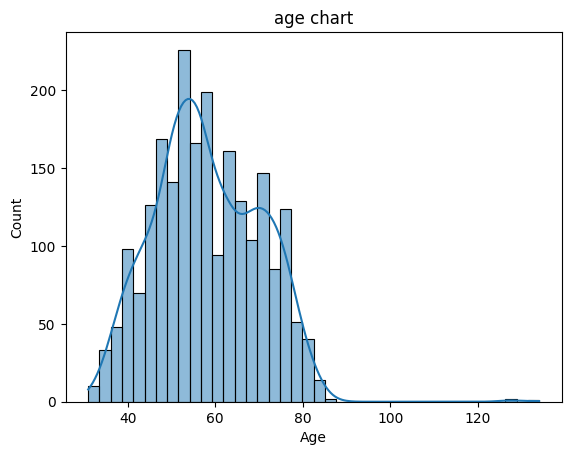

In [ ]:
df["Age"]=2027-df["Year_Birth"]
sns.histplot(df["Age"], bins=40, kde=True)
plt.title("age chart")
plt.show()

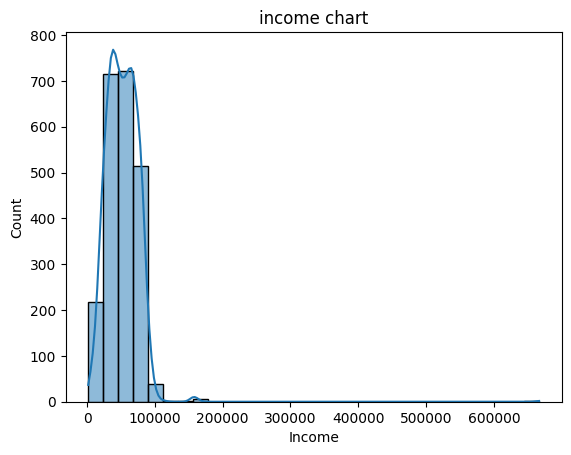

In [ ]:

sns.histplot(df["Income"], bins=30, kde=True)
plt.title("income chart")
plt.show()

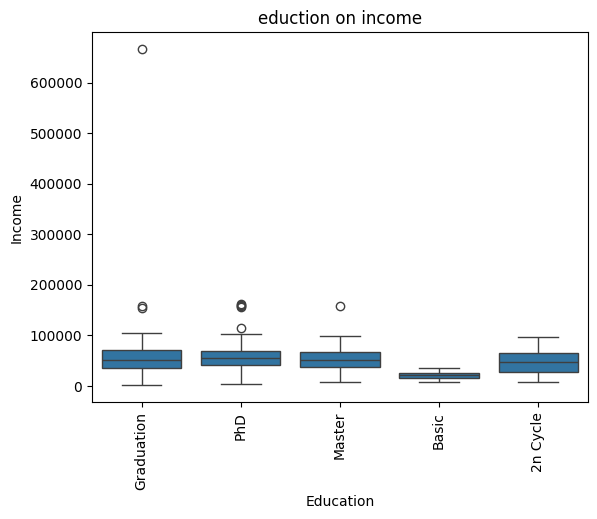

In [ ]:
sns.boxplot(x= "Education" , y="Income" , data = df)
plt.xticks(rotation=90)
plt.title("eduction on income")
plt.show()

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
corr = df[["Income","Age","Recency","NumDealsPurchases","NumWebPurchases","NumCatalogPurchases"]].corr()

In [ ]:
corr

,Income,Age,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases
0,58138.0,70,58,3,8,10
1,46344.0,73,38,2,1,1
2,71613.0,62,26,1,8,2
3,26646.0,43,26,2,2,0
4,58293.0,46,94,5,5,3
...,...,...,...,...,...,...
2235,61223.0,60,46,2,9,3
2236,64014.0,81,56,7,8,2
2237,56981.0,46,91,1,2,3
2238,69245.0,71,8,2,6,5


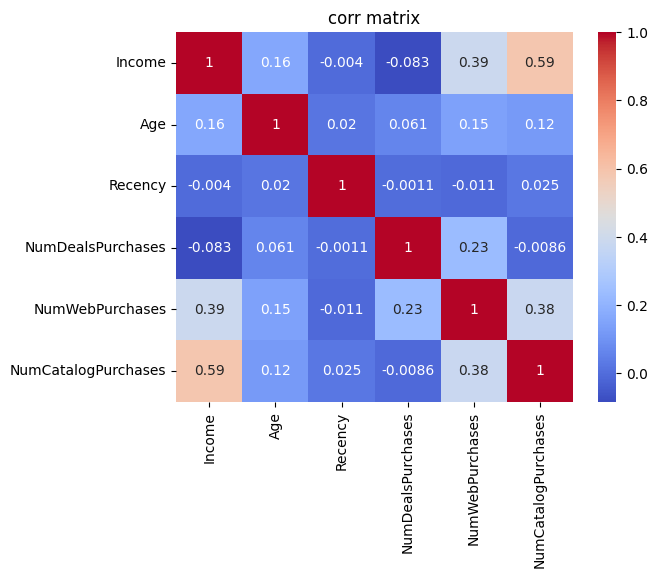

In [ ]:
sns.heatmap(corr , annot= True  , cmap="coolwarm")
plt.title("corr matrix")
plt.show()

In [ ]:
pivot_income= df.pivot_table(index="Education",columns="Marital_Status",values="Income",aggfunc="mean")

In [ ]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


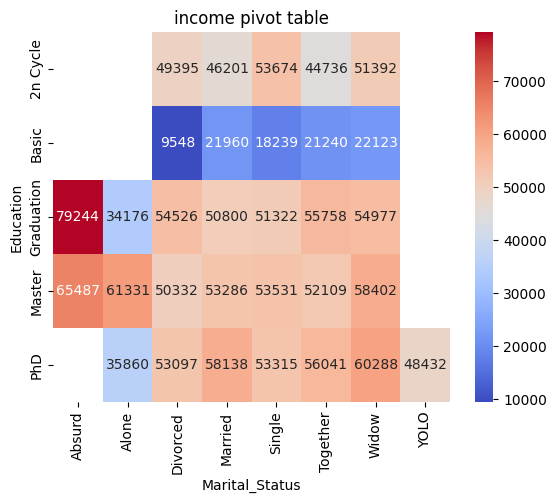

In [ ]:
sns.heatmap(pivot_income,annot=True, fmt=".0f" ,cmap="coolwarm")
plt.title("income pivot table")
plt.show()

In [ ]:
group1 = df.groupby("Education")["Income"].mean().sort_values(ascending=False)

In [ ]:
group1

,Income
Education,
PhD,56145.313929
Master,52917.534247
Graduation,52720.373656
2n Cycle,47633.190000
Basic,20306.259259


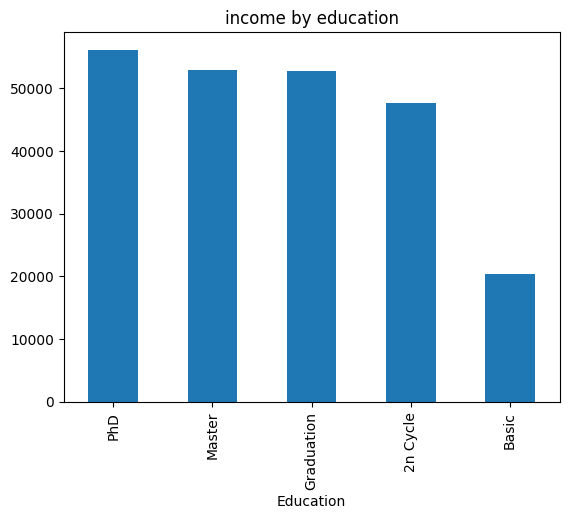

In [ ]:
group1.plot(kind="bar")
plt.title("income by education")
9plt.show()

In [ ]:
df["AcceptedAny"]=df["AcceptedCmp1"]+df["AcceptedCmp2"]+df["AcceptedCmp3"]+df["AcceptedCmp4"]

In [ ]:
df["AcceptedAny"].unique()

array([0, 1, 2, 3])

In [ ]:
group2=df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)

In [ ]:
group2

,AcceptedAny
Marital_Status,
Absurd,0.500000
Alone,0.333333
Widow,0.259740
Divorced,0.237069
Married,0.226852
Single,0.222917
Together,0.213793
YOLO,0.000000


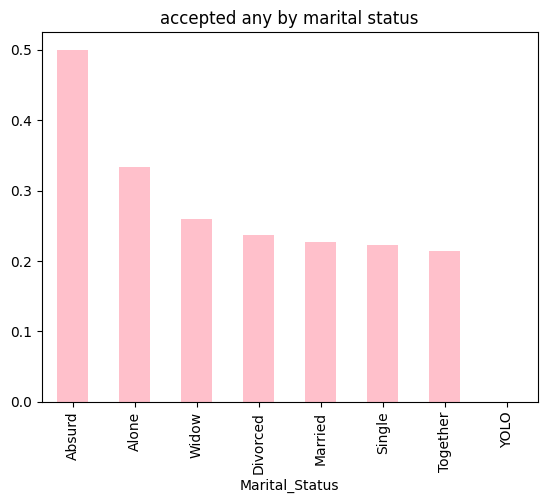

In [ ]:
group2.plot(kind="bar",color= "pink")
plt.title("accepted any by marital status")
plt.show()

In [ ]:
bins=[19,30,40 ,60,70,90]

In [ ]:
labels=["18-29","30-39","40-49","60-69","70-90"]

In [ ]:
=pd.cut(df["Age"], bins=bins, labels=labels)df["Age_Group"]

In [ ]:
df["Age_Group"]

In [ ]:
group3=df.groupby("Age_Group")("Income") .mean()

In [ ]:
group3

,AcceptedAny
Age,
30-39,0.283333
70-90,0.259179
40-49,0.217839
60-69,0.196721
18-29,NaN


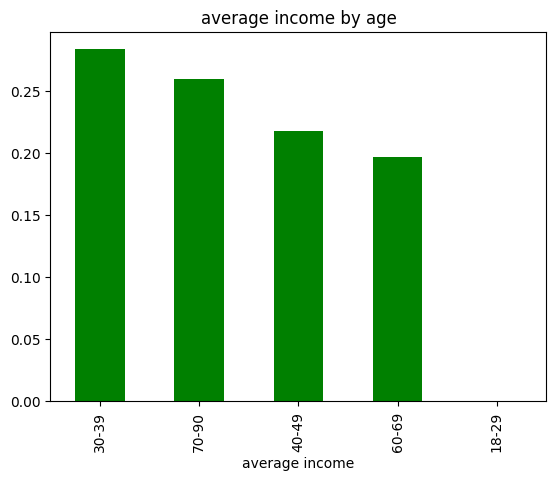

In [ ]:
group3.plot(kind="bar" , color="green")
plt.title("average income by age")
plt.xlabel("average income")
plt.show()

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,AcceptedAny,Age_Group
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,70,0,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,73,0,70-90
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,62,0,60-69
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,43,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,46,0,40-49


In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'AcceptedAny', 'Age_Group'],
      dtype='object')

In [ ]:
df["Total_spending"] =df[spend_cols].sum(axis=1)

In [ ]:
Age- Income -Total_Spending-NumWebPurchases-NumStorePurchases-NumWebVisitsMonth-NumWebVisitsMonth-

In [ ]:
feature = ["Age" , "Income" , "Total_spending" , "NumWebPurchases" ,"NumStorePurchases" , "NumWebVisitsMonth" , "Recency"]

In [ ]:
x = df[feature].dropna().copy()

In [ ]:
x

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,70,58138.0,1617,8,4,7,58
1,73,46344.0,27,1,2,5,38
2,62,71613.0,776,8,10,4,26
3,43,26646.0,53,2,4,6,26
4,46,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,60,61223.0,1341,9,4,5,46
2236,81,64014.0,444,8,5,7,56
2237,46,56981.0,1241,2,13,6,91
2238,71,69245.0,843,6,10,3,8


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Ensure x is clean before scaling
x = df[feature].dropna().copy()

scaler = StandardScaler()
X_scaler = scaler.fit_transform(x)

# Diagnostic check to confirm no NaNs remain after scaling
if np.isnan(X_scaler).any():
    print("Warning: NaNs still present in 'X_scaler' after scaling.")
else:
    print("No NaNs found in 'X_scaler' after scaling. Ready for KMeans.")

No NaNs found in 'X_scaler' after scaling. Ready for KMeans.


In [ ]:
df.dropna(inplace=True)

In [ ]:
X_scaler

array([[ 0.98534473,  0.2340627 ,  1.67941681, ..., -0.55078479,
         0.69390374,  0.30703926],
       [ 1.23573295, -0.23455948, -0.96127545, ..., -1.1661254 ,
        -0.13046347, -0.38366418],
       [ 0.3176428 ,  0.76947764,  0.28267329, ...,  1.29523705,
        -0.54264708, -0.79808624],
       ...,
       [-1.01776106,  0.18809052,  1.05495122, ...,  2.21824797,
         0.28172013,  1.44669994],
       [ 1.06880747,  0.67538765,  0.39394775, ...,  1.29523705,
        -0.95483068, -1.41971934],
       [ 1.23573295,  0.02470453, -0.7204576 , ..., -0.55078479,
         0.69390374, -0.31459383]])

In [ ]:
from sklearn.cluster import KMeans



In [ ]:
wscc = []

In [ ]:
for i in range(2,10) :
  kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
  kmeans.fit(X_scaler)
  wscc.append(kmeans.inertia_)

In [ ]:
wscc

[10218.620143748776,
 9007.769562675718,
 8158.801654022348,
 7568.10081534747,
 7094.254065467428,
 6534.098565679779,
 6151.761818251987,
 5855.611766130684]

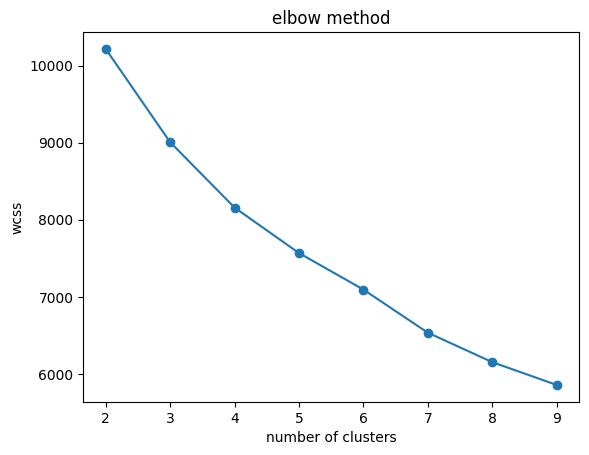

In [ ]:
plt.plot(range(2,10),wscc ,marker = "o")
plt.title("elbow method")
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=4)
df["Cluster"] = kmeans.fit_predict(X_scaler)

In [ ]:
df["Cluster"]

,Cluster
0,0
1,3
2,0
3,2
4,3
...,...
2235,0
2236,0
2237,1
2238,1


In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_spending,Age,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,1617,70,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,27,73,3
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,776,62,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,53,43,2
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,422,46,3


In [ ]:
cluster_summary = df.groupby("Cluster") [feature].mean()

In [ ]:
cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,61.404255,60512.264990,894.508704,7.531915,8.081238,6.143133,44.094778
1,58.538869,77776.081272,1301.575972,4.466431,8.443463,2.411661,51.462898
2,49.315946,31169.201192,98.533532,2.150522,3.065574,6.956781,43.157973
3,67.004329,42336.086580,173.181818,2.571429,3.984848,5.580087,60.017316


In [ ]:
df["Cluster"].value_counts()

,count
Cluster,
2,671
1,566
0,517
3,462


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaler)
df["PCA1"] , df["PCA2"] = X_pca[:,0] , X_pca[:,1]

In [ ]:
X_pca

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]])

In [ ]:
df["PCA1"]

,PCA1
0,1.107519
1,-1.336734
2,1.882277
3,-1.784359
4,0.020363
...,...
2235,1.248177
2236,0.508708
2237,1.153597
2238,1.887680


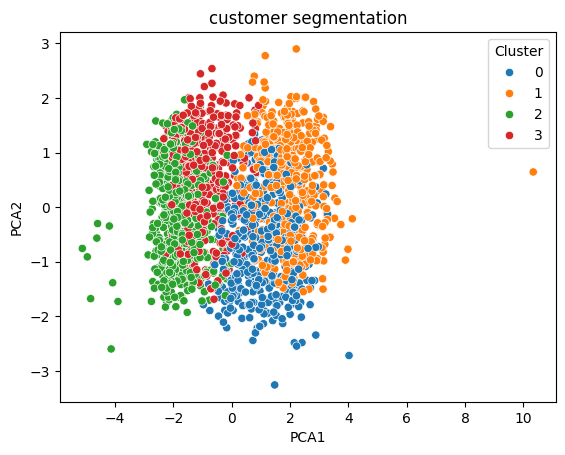

In [ ]:
sns.scatterplot(x="PCA1" , y="PCA2" , hue = "Cluster" , data=df , palette= "tab10")
plt.title("customer segmentation")
plt.show()

In [ ]:

cluster_summary

,Age,Income,Total_spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,61.404255,60512.264990,894.508704,7.531915,8.081238,6.143133,44.094778
1,58.538869,77776.081272,1301.575972,4.466431,8.443463,2.411661,51.462898
2,49.315946,31169.201192,98.533532,2.150522,3.065574,6.956781,43.157973
3,67.004329,42336.086580,173.181818,2.571429,3.984848,5.580087,60.017316
